In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [3]:
data = pd.read_csv("/content/train.csv")

print("Dataset shape:", data.shape)

data.head()

Dataset shape: (2930, 82)


,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [4]:
print("Target column:", "SalePrice")

print("SalePrice missing values:",
      data["SalePrice"].isnull().sum())

Target column: SalePrice
SalePrice missing values: 0


In [5]:
features = [
    "Overall Qual",
    "Gr Liv Area",
    "Garage Cars",
    "Total Bsmt SF",
    "Year Built"
]

target = "SalePrice"

X = data[features].copy()
y = data[target].copy()

print("Selected features:")
print(features)

Selected features:
['Overall Qual', 'Gr Liv Area', 'Garage Cars', 'Total Bsmt SF', 'Year Built']


In [6]:
X = X.fillna(X.median())

valid = y.notna()

X = X[valid]
y = y[valid]

print("Rows used:", len(X))
print("Missing values:")
print(X.isnull().sum())

Rows used: 2930
Missing values:
Overall Qual     0
Gr Liv Area      0
Garage Cars      0
Total Bsmt SF    0
Year Built       0
dtype: int64


In [7]:
np.random.seed(42)

X["Irrelevant"] = np.random.normal(
    0,
    1,
    len(X)
)

print("Irrelevant feature added.")

Irrelevant feature added.


In [8]:
X["Redundant"] = X["Gr Liv Area"] * 2

print("Redundant feature added.")

Redundant feature added.


In [9]:
feature_sets = {

    "Important Features": [
        "Overall Qual",
        "Gr Liv Area",
        "Garage Cars",
        "Total Bsmt SF",
        "Year Built"
    ],

    "Important + Irrelevant": [
        "Overall Qual",
        "Gr Liv Area",
        "Garage Cars",
        "Total Bsmt SF",
        "Year Built",
        "Irrelevant"
    ],

    "Important + Redundant": [
        "Overall Qual",
        "Gr Liv Area",
        "Garage Cars",
        "Total Bsmt SF",
        "Year Built",
        "Redundant"
    ]
}

for name, features_used in feature_sets.items():
    print("\n", name)
    print(features_used)


 Important Features
['Overall Qual', 'Gr Liv Area', 'Garage Cars', 'Total Bsmt SF', 'Year Built']

 Important + Irrelevant
['Overall Qual', 'Gr Liv Area', 'Garage Cars', 'Total Bsmt SF', 'Year Built', 'Irrelevant']

 Important + Redundant
['Overall Qual', 'Gr Liv Area', 'Garage Cars', 'Total Bsmt SF', 'Year Built', 'Redundant']


In [10]:
train_index, test_index = train_test_split(
    X.index,
    test_size=0.20,
    random_state=42
)

y_train = y.loc[train_index]
y_test = y.loc[test_index]

print("Training samples:", len(train_index))
print("Testing samples:", len(test_index))

Training samples: 2344
Testing samples: 586


In [11]:
results = []

for set_name, selected_features in feature_sets.items():

    X_train = X.loc[train_index, selected_features]
    X_test = X.loc[test_index, selected_features]

    # Scale features
    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # -------------------------
    # Linear Regression
    # -------------------------

    linear_model = LinearRegression()

    linear_model.fit(
        X_train_scaled,
        y_train
    )

    linear_prediction = linear_model.predict(
        X_test_scaled
    )

    linear_rmse = np.sqrt(
        mean_squared_error(
            y_test,
            linear_prediction
        )
    )

    linear_mae = mean_absolute_error(
        y_test,
        linear_prediction
    )

    linear_r2 = r2_score(
        y_test,
        linear_prediction
    )

    results.append([
        set_name,
        "Linear Regression",
        linear_rmse,
        linear_mae,
        linear_r2
    ])

    # -------------------------
    # Lasso Regression
    # -------------------------

    lasso_model = Lasso(
        alpha=100,
        max_iter=10000
    )

    lasso_model.fit(
        X_train_scaled,
        y_train
    )

    lasso_prediction = lasso_model.predict(
        X_test_scaled
    )

    lasso_rmse = np.sqrt(
        mean_squared_error(
            y_test,
            lasso_prediction
        )
    )

    lasso_mae = mean_absolute_error(
        y_test,
        lasso_prediction
    )

    lasso_r2 = r2_score(
        y_test,
        lasso_prediction
    )

    results.append([
        set_name,
        "Lasso Regression",
        lasso_rmse,
        lasso_mae,
        lasso_r2
    ])

print("Both models completed successfully.")

Both models completed successfully.


In [12]:
results_df = pd.DataFrame(
    results,
    columns=[
        "Feature Set",
        "Model",
        "RMSE",
        "MAE",
        "R2"
    ]
)

results_df.round(3)

,Feature Set,Model,RMSE,MAE,R2
0,Important Features,Linear Regression,40342.628,25885.164,0.797
1,Important Features,Lasso Regression,40365.537,25879.411,0.797
2,Important + Irrelevant,Linear Regression,40333.303,25911.341,0.797
3,Important + Irrelevant,Lasso Regression,40355.460,25901.754,0.797
4,Important + Redundant,Linear Regression,40342.628,25885.164,0.797
5,Important + Redundant,Lasso Regression,40365.833,25878.983,0.797


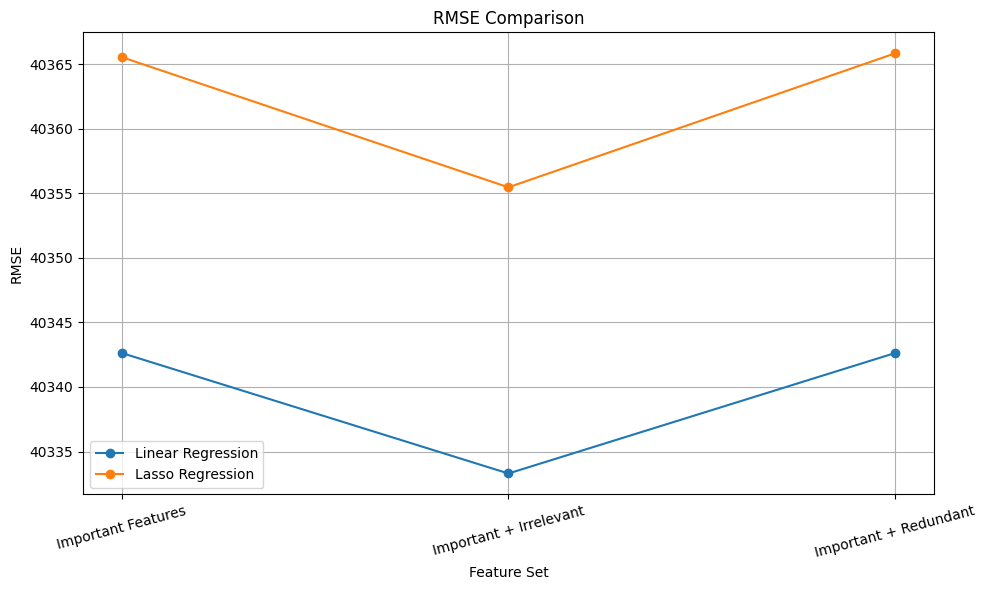

In [13]:
plt.figure(figsize=(10, 6))

for model in results_df["Model"].unique():

    model_data = results_df[
        results_df["Model"] == model
    ]

    plt.plot(
        model_data["Feature Set"],
        model_data["RMSE"],
        marker="o",
        label=model
    )

plt.xlabel("Feature Set")
plt.ylabel("RMSE")
plt.title("RMSE Comparison")

plt.xticks(rotation=15)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

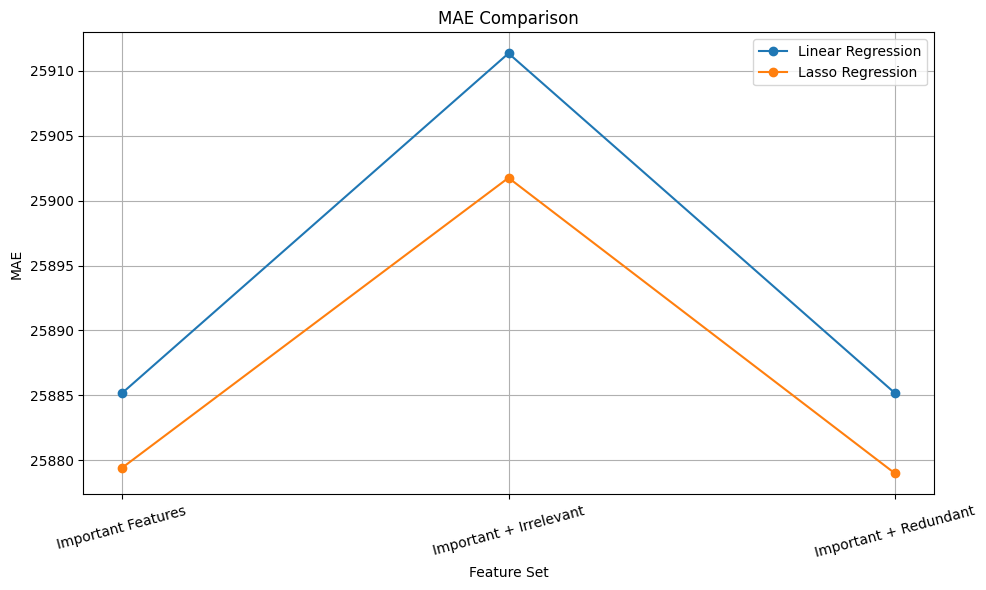

In [14]:
plt.figure(figsize=(10, 6))

for model in results_df["Model"].unique():

    model_data = results_df[
        results_df["Model"] == model
    ]

    plt.plot(
        model_data["Feature Set"],
        model_data["MAE"],
        marker="o",
        label=model
    )

plt.xlabel("Feature Set")
plt.ylabel("MAE")
plt.title("MAE Comparison")

plt.xticks(rotation=15)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

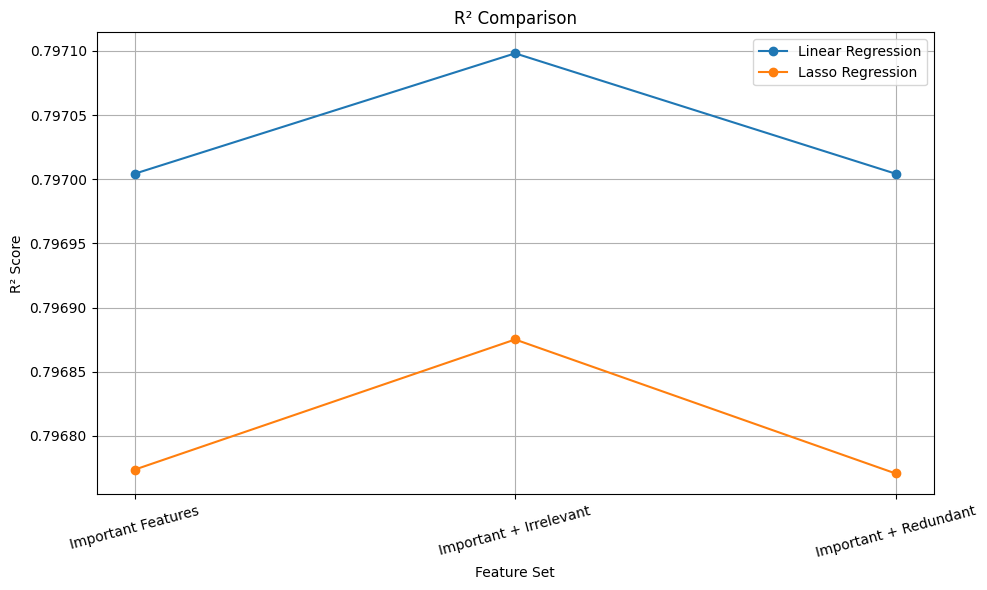

In [15]:
plt.figure(figsize=(10, 6))

for model in results_df["Model"].unique():

    model_data = results_df[
        results_df["Model"] == model
    ]

    plt.plot(
        model_data["Feature Set"],
        model_data["R2"],
        marker="o",
        label=model
    )

plt.xlabel("Feature Set")
plt.ylabel("R² Score")
plt.title("R² Comparison")

plt.xticks(rotation=15)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [16]:
summary = results_df.pivot_table(
    index="Feature Set",
    columns="Model",
    values=["RMSE", "MAE", "R2"]
)

summary.round(3)

MAE                                 R2  \
Model                  Lasso Regression Linear Regression Lasso Regression   
Feature Set                                                                  
Important + Irrelevant        25901.754         25911.341            0.797   
Important + Redundant         25878.983         25885.164            0.797   
Important Features            25879.411         25885.164            0.797   

                                                     RMSE                    
Model                  Linear Regression Lasso Regression Linear Regression  
Feature Set                                                                  
Important + Irrelevant             0.797        40355.460         40333.303  
Important + Redundant              0.797        40365.833         40342.628  
Important Features                 0.797        40365.537         40342.628